In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# load the data
df = pd.read_csv('../data/pcos_prediction_dataset.csv')
df.head()

,Country,Age,BMI,Menstrual Regularity,Hirsutism,Acne Severity,Family History of PCOS,Insulin Resistance,Lifestyle Score,Stress Levels,Urban/Rural,Socioeconomic Status,Awareness of PCOS,Fertility Concerns,Undiagnosed PCOS Likelihood,Ethnicity,Diagnosis
0,Madagascar,26,Overweight,Regular,Yes,Severe,Yes,Yes,2,Low,Rural,High,Yes,No,0.107938,Hispanic,Yes
1,Vietnam,16,Underweight,Regular,Yes,NaN,No,Yes,4,High,Rural,Middle,Yes,No,0.156729,Other,No
2,Somalia,41,Normal,Regular,No,Moderate,No,No,7,Medium,Urban,Middle,Yes,Yes,0.202901,Other,No
3,Malawi,27,Normal,Irregular,No,Mild,No,No,10,Low,Urban,High,Yes,No,0.073926,Caucasian,Yes
4,France,26,Overweight,Irregular,Yes,NaN,No,No,7,Medium,Urban,Middle,No,No,0.229266,Caucasian,No


In [9]:
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

In [10]:
df.head()

,country,age,bmi,menstrual_regularity,hirsutism,acne_severity,family_history_of_pcos,insulin_resistance,lifestyle_score,stress_levels,urban/rural,socioeconomic_status,awareness_of_pcos,fertility_concerns,undiagnosed_pcos_likelihood,ethnicity,diagnosis
0,Madagascar,26,Overweight,Regular,Yes,Severe,Yes,Yes,2,Low,Rural,High,Yes,No,0.107938,Hispanic,Yes
1,Vietnam,16,Underweight,Regular,Yes,NaN,No,Yes,4,High,Rural,Middle,Yes,No,0.156729,Other,No
2,Somalia,41,Normal,Regular,No,Moderate,No,No,7,Medium,Urban,Middle,Yes,Yes,0.202901,Other,No
3,Malawi,27,Normal,Irregular,No,Mild,No,No,10,Low,Urban,High,Yes,No,0.073926,Caucasian,Yes
4,France,26,Overweight,Irregular,Yes,NaN,No,No,7,Medium,Urban,Middle,No,No,0.229266,Caucasian,No


In [11]:
### Check missing values
df.isnull().sum()

country                            0
age                                0
bmi                                0
menstrual_regularity               0
hirsutism                          0
acne_severity                  60085
family_history_of_pcos             0
insulin_resistance                 0
lifestyle_score                    0
stress_levels                      0
urban/rural                        0
socioeconomic_status               0
awareness_of_pcos                  0
fertility_concerns                 0
undiagnosed_pcos_likelihood        0
ethnicity                          0
diagnosis                          0
dtype: int64

In [23]:
df.tail(20)

,country,age,bmi,menstrual_regularity,hirsutism,acne_severity,family_history_of_pcos,insulin_resistance,lifestyle_score,stress_levels,urban/rural,socioeconomic_status,awareness_of_pcos,fertility_concerns,undiagnosed_pcos_likelihood,ethnicity,diagnosis
119980,Somalia,18,Underweight,Irregular,No,Mild,Yes,Yes,4,High,Urban,Low,Yes,Yes,0.115082,Other,No
119981,Ecuador,15,Normal,Regular,Yes,NaN,No,Yes,4,High,Urban,High,Yes,No,0.082719,Asian,No
119982,Zimbabwe,21,Normal,Regular,Yes,Severe,Yes,No,1,Low,Rural,High,No,Yes,0.161627,Caucasian,No
119983,Afghanistan,30,Overweight,Irregular,Yes,Mild,No,No,9,Medium,Rural,Middle,Yes,No,0.070892,Other,No
119984,Brazil,36,Obese,Regular,Yes,Mild,No,No,5,Low,Urban,Middle,No,No,0.104384,African,No
119985,Zambia,40,Normal,Regular,Yes,NaN,Yes,No,7,Medium,Urban,High,Yes,No,0.172917,African,No
119986,Spain,37,Normal,Regular,No,Severe,No,No,7,Medium,Urban,Middle,Yes,Yes,0.249953,Caucasian,No
119987,Egypt,36,Normal,Regular,No,NaN,No,No,2,Medium,Urban,Low,No,Yes,0.085712,Hispanic,No
119988,Ivory Coast,18,Underweight,Regular,No,Mild,No,No,4,Medium,Urban,Middle,Yes,Yes,0.215998,African,No
119989,Mozambique,36,Obese,Regular,No,Mild,Yes,No,2,Medium,Urban,Middle,No,No,0.086842,Asian,No


### Preprocessed Data

In [17]:
df.shape

(120000, 17)

##### Country

In [ ]:
### country
df.country.nunique()

77

In [22]:
df.country.value_counts().tail(30)

country
Guatemala         1547
Turkey            1546
Somalia           1545
Bangladesh        1544
Cameroon          1543
Chad              1541
Poland            1540
Sri Lanka         1535
Niger             1534
Iraq              1532
Egypt             1530
Saudi Arabia      1529
Nigeria           1528
Zimbabwe          1528
Australia         1526
Mozambique        1523
North Korea       1523
Malaysia          1522
Syria             1517
United Kingdom    1514
Taiwan            1510
Benin             1509
Nepal             1509
Venezuela         1508
Tanzania          1501
Netherlands       1500
Algeria           1496
Uganda            1487
Zambia            1479
Cambodia          1441
Name: count, dtype: int64

In [52]:
df[df['country'] == 'Bangladesh']

,country,age,bmi,menstrual_regularity,hirsutism,acne_severity,family_history_of_pcos,insulin_resistance,lifestyle_score,stress_levels,urban/rural,socioeconomic_status,awareness_of_pcos,fertility_concerns,undiagnosed_pcos_likelihood,ethnicity,diagnosis
50,Bangladesh,37,Normal,Regular,No,NaN,No,No,3,Medium,Urban,Low,Yes,Yes,0.052753,African,No
85,Bangladesh,34,Normal,Regular,No,Mild,Yes,No,1,High,Urban,Low,Yes,No,0.184029,Caucasian,No
88,Bangladesh,23,Normal,Regular,Yes,NaN,No,No,10,Medium,Urban,Middle,Yes,No,0.166652,Other,No
253,Bangladesh,20,Normal,Irregular,Yes,NaN,No,No,6,Low,Urban,Low,Yes,Yes,0.078049,Other,No
266,Bangladesh,35,Overweight,Regular,No,Moderate,Yes,No,6,Medium,Rural,Middle,No,No,0.194960,Asian,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119623,Bangladesh,18,Normal,Regular,Yes,Moderate,No,No,4,Low,Rural,Middle,No,No,0.115560,Hispanic,No
119646,Bangladesh,44,Overweight,Regular,No,NaN,No,Yes,1,High,Urban,Low,Yes,Yes,0.196038,Caucasian,No
119675,Bangladesh,45,Normal,Irregular,Yes,NaN,Yes,Yes,6,High,Rural,Middle,No,Yes,0.178414,Hispanic,No
119691,Bangladesh,32,Normal,Regular,No,NaN,No,No,2,High,Urban,Middle,No,Yes,0.239536,Asian,No


In [25]:
# check missing values
df.country.isnull().sum()

np.int64(0)

##### Age

In [29]:
df.age.nunique()

35

In [32]:
df.age.describe()

count    120000.000000
mean         31.980508
std          10.096799
min          15.000000
25%          23.000000
50%          32.000000
75%          41.000000
max          49.000000
Name: age, dtype: float64

In [38]:
df[df['age'] >= 45]

,country,age,bmi,menstrual_regularity,hirsutism,acne_severity,family_history_of_pcos,insulin_resistance,lifestyle_score,stress_levels,urban/rural,socioeconomic_status,awareness_of_pcos,fertility_concerns,undiagnosed_pcos_likelihood,ethnicity,diagnosis
8,United States,47,Normal,Regular,Yes,NaN,Yes,No,1,Medium,Urban,Low,Yes,No,0.103628,Asian,Yes
12,Argentina,46,Underweight,Regular,No,Mild,No,Yes,1,Medium,Urban,Low,No,Yes,0.232999,Caucasian,No
17,France,48,Overweight,Regular,Yes,NaN,No,No,8,Low,Urban,Middle,No,No,0.224517,African,No
26,Vietnam,47,Normal,Regular,No,NaN,Yes,No,9,Low,Rural,Low,Yes,No,0.125385,Hispanic,No
32,Taiwan,49,Normal,Regular,No,Mild,No,Yes,10,Medium,Rural,Middle,Yes,Yes,0.183763,Other,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119955,North Korea,46,Obese,Regular,No,NaN,No,No,10,High,Urban,Middle,No,No,0.150548,Hispanic,No
119966,United Kingdom,46,Obese,Irregular,Yes,NaN,Yes,No,7,Medium,Rural,Middle,Yes,No,0.099763,African,No
119968,Ecuador,48,Normal,Irregular,No,Mild,No,Yes,3,High,Urban,Low,Yes,No,0.081860,Other,No
119977,Burkina Faso,47,Overweight,Irregular,No,Mild,No,No,6,Medium,Rural,Middle,Yes,No,0.057751,African,No


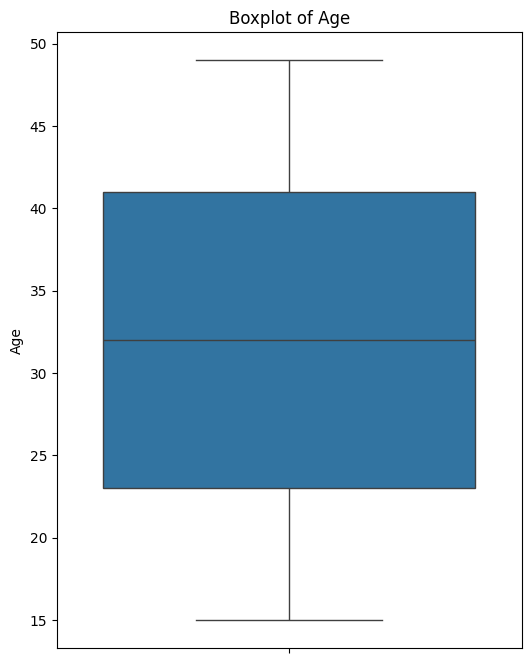

In [39]:
plt.figure(figsize=(6, 8))
sns.boxplot(y=df['age'])
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

In [43]:
df[(df['age'] <= 16) | (df['age'] >= 45)] 

,country,age,bmi,menstrual_regularity,hirsutism,acne_severity,family_history_of_pcos,insulin_resistance,lifestyle_score,stress_levels,urban/rural,socioeconomic_status,awareness_of_pcos,fertility_concerns,undiagnosed_pcos_likelihood,ethnicity,diagnosis
1,Vietnam,16,Underweight,Regular,Yes,NaN,No,Yes,4,High,Rural,Middle,Yes,No,0.156729,Other,No
8,United States,47,Normal,Regular,Yes,NaN,Yes,No,1,Medium,Urban,Low,Yes,No,0.103628,Asian,Yes
12,Argentina,46,Underweight,Regular,No,Mild,No,Yes,1,Medium,Urban,Low,No,Yes,0.232999,Caucasian,No
17,France,48,Overweight,Regular,Yes,NaN,No,No,8,Low,Urban,Middle,No,No,0.224517,African,No
26,Vietnam,47,Normal,Regular,No,NaN,Yes,No,9,Low,Rural,Low,Yes,No,0.125385,Hispanic,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119977,Burkina Faso,47,Overweight,Irregular,No,Mild,No,No,6,Medium,Rural,Middle,Yes,No,0.057751,African,No
119981,Ecuador,15,Normal,Regular,Yes,NaN,No,Yes,4,High,Urban,High,Yes,No,0.082719,Asian,No
119990,Yemen,45,Overweight,Regular,Yes,NaN,No,No,6,High,Urban,Low,No,No,0.117242,Hispanic,No
119997,Cambodia,16,Normal,Regular,No,Moderate,No,No,9,Medium,Rural,Low,Yes,Yes,0.236241,African,Yes


In [45]:
### check missing values
df.age.isnull().sum()

np.int64(0)

In [50]:
df[df['country'] == 'Bangladesh']['age'].agg(['max', 'min'])

max    49
min    15
Name: age, dtype: int64

##### Bmi

In [53]:
df.bmi.value_counts()

bmi
Normal         60080
Overweight     36038
Obese          17945
Underweight     5937
Name: count, dtype: int64

In [55]:
## check missing values
df.bmi.isnull().sum()

np.int64(0)

In [59]:
df[df['country'] == 'Bangladesh'].groupby('bmi')['age'].mean()

bmi
Normal         32.017128
Obese          33.061475
Overweight     32.310722
Underweight    32.773810
Name: age, dtype: float64

In [60]:
df.columns

Index(['country', 'age', 'bmi', 'menstrual_regularity', 'hirsutism',
       'acne_severity', 'family_history_of_pcos', 'insulin_resistance',
       'lifestyle_score', 'stress_levels', 'urban/rural',
       'socioeconomic_status', 'awareness_of_pcos', 'fertility_concerns',
       'undiagnosed_pcos_likelihood', 'ethnicity', 'diagnosis'],
      dtype='str')

##### Menstrual Regularity

In [61]:
df.menstrual_regularity.value_counts()

menstrual_regularity
Regular      83941
Irregular    36059
Name: count, dtype: int64

In [63]:
# unique values
df.menstrual_regularity.unique()

<StringArray>
['Regular', 'Irregular']
Length: 2, dtype: str

##### Hirsutism

In [64]:
df.hirsutism.value_counts()

hirsutism
No     72039
Yes    47961
Name: count, dtype: int64

In [65]:
### check missing values
df.hirsutism.isnull().sum()

np.int64(0)

##### Acne Severity

In [66]:
df.acne_severity.value_counts()

acne_severity
Mild        35822
Moderate    18072
Severe       6021
Name: count, dtype: int64

In [111]:
missing_rows = df[df['acne_severity'].isnull()]
missing_rows

,country,age,bmi,menstrual_regularity,hirsutism,acne_severity,family_history_of_pcos,insulin_resistance,lifestyle_score,stress_levels,urban/rural,socioeconomic_status,awareness_of_pcos,fertility_concerns,undiagnosed_pcos_likelihood,ethnicity,diagnosis
1,Vietnam,16,Underweight,Regular,Yes,NaN,No,Yes,4,High,Rural,Middle,Yes,No,0.156729,Other,No
4,France,26,Overweight,Irregular,Yes,NaN,No,No,7,Medium,Urban,Middle,No,No,0.229266,Caucasian,No
5,Rwanda,17,Overweight,Irregular,No,NaN,No,Yes,3,Low,Urban,High,Yes,Yes,0.209841,African,No
8,United States,47,Normal,Regular,Yes,NaN,Yes,No,1,Medium,Urban,Low,Yes,No,0.103628,Asian,Yes
11,India,20,Normal,Regular,No,NaN,Yes,No,2,Medium,Urban,Middle,Yes,Yes,0.180213,Caucasian,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119992,Pakistan,22,Obese,Irregular,No,NaN,No,Yes,7,Medium,Rural,Low,Yes,No,0.071900,African,No
119993,Rwanda,17,Overweight,Regular,No,NaN,Yes,No,4,High,Urban,High,No,No,0.099718,Hispanic,No
119996,Mozambique,35,Overweight,Regular,No,NaN,No,No,5,Low,Rural,High,Yes,Yes,0.167482,Asian,No
119998,Benin,15,Obese,Regular,Yes,NaN,Yes,Yes,1,Medium,Rural,High,No,No,0.119993,Hispanic,No


In [108]:
missing_percent = df.isnull().mean() * 100
missing_percent

country                         0.000000
age                             0.000000
bmi                             0.000000
menstrual_regularity            0.000000
hirsutism                       0.000000
acne_severity                  50.070833
family_history_of_pcos          0.000000
insulin_resistance              0.000000
lifestyle_score                 0.000000
stress_levels                   0.000000
urban/rural                     0.000000
socioeconomic_status            0.000000
awareness_of_pcos               0.000000
fertility_concerns              0.000000
undiagnosed_pcos_likelihood     0.000000
ethnicity                       0.000000
diagnosis                       0.000000
dtype: float64

##### Family History of pcos

In [80]:
df.family_history_of_pcos.value_counts()

family_history_of_pcos
No     84028
Yes    35972
Name: count, dtype: int64

In [81]:
#### check missing values
df.family_history_of_pcos.isnull().sum()

np.int64(0)

In [82]:
df.columns

Index(['country', 'age', 'bmi', 'menstrual_regularity', 'hirsutism',
       'acne_severity', 'family_history_of_pcos', 'insulin_resistance',
       'lifestyle_score', 'stress_levels', 'urban/rural',
       'socioeconomic_status', 'awareness_of_pcos', 'fertility_concerns',
       'undiagnosed_pcos_likelihood', 'ethnicity', 'diagnosis'],
      dtype='str')

##### Insulin Resistance'

In [83]:
df.insulin_resistance.value_counts()

insulin_resistance
No     90183
Yes    29817
Name: count, dtype: int64

In [84]:
### check missing values
df.insulin_resistance.isnull().sum()

np.int64(0)

##### Lifestyle Score

In [91]:
df.lifestyle_score.value_counts()

lifestyle_score
5     12191
6     12131
9     12040
10    12014
8     11999
2     11986
1     11975
7     11962
3     11934
4     11768
Name: count, dtype: int64

In [92]:
### check missing values
df.lifestyle_score.isnull().sum()

np.int64(0)

##### Stress Levels

In [93]:
df.stress_levels.value_counts()

stress_levels
Medium    59959
Low       36118
High      23923
Name: count, dtype: int64

In [94]:
### Check missing values
df.stress_levels.isnull().sum()

np.int64(0)

##### Urban_Rural

In [95]:
df['urban/rural'].value_counts()

urban/rural
Urban    83943
Rural    36057
Name: count, dtype: int64

In [96]:
### Check missing values
df['urban/rural'].isnull().sum()

np.int64(0)

##### Socioeconomic Status

In [97]:
df.socioeconomic_status.value_counts()

socioeconomic_status
Middle    59860
Low       35954
High      24186
Name: count, dtype: int64

In [98]:
### check missing values
df.socioeconomic_status.isnull().sum()

np.int64(0)

In [112]:
df.columns

Index(['country', 'age', 'bmi', 'menstrual_regularity', 'hirsutism',
       'acne_severity', 'family_history_of_pcos', 'insulin_resistance',
       'lifestyle_score', 'stress_levels', 'urban/rural',
       'socioeconomic_status', 'awareness_of_pcos', 'fertility_concerns',
       'undiagnosed_pcos_likelihood', 'ethnicity', 'diagnosis'],
      dtype='str')

##### Undiagnosed Pcos Likelihood

In [122]:
df.undiagnosed_pcos_likelihood.value_counts()

undiagnosed_pcos_likelihood
0.107938    1
0.156729    1
0.202901    1
0.073926    1
0.229266    1
           ..
0.090663    1
0.167482    1
0.236241    1
0.119993    1
0.223073    1
Name: count, Length: 120000, dtype: int64

##### Awareness of pcos

In [114]:
df.awareness_of_pcos.value_counts()

awareness_of_pcos
Yes    71891
No     48109
Name: count, dtype: int64

##### Fertility Concerns

In [115]:
df.fertility_concerns.value_counts()

fertility_concerns
No     72205
Yes    47795
Name: count, dtype: int64

In [117]:
### check missing values
df.fertility_concerns.isnull().sum()

np.int64(0)

##### Ethnicity

In [118]:
df.ethnicity.value_counts()

ethnicity
African      24285
Hispanic     24241
Caucasian    23950
Other        23876
Asian        23648
Name: count, dtype: int64

##### Diagnosis

In [119]:
df.diagnosis.value_counts()

diagnosis
No     107405
Yes     12595
Name: count, dtype: int64

In [121]:
### check missing values
df.diagnosis.isnull().sum()

np.int64(0)